# Simulated Image Data with Confounding

[Explain the dataset]

Models

[Explain the models]

Experiments

[Explain the experiments, varying N consistency, varying bz etc.]

Code Overview

[Explain functions]

---

#### Imports

In [1]:
import os
import re
import torch
import datetime

import pandas as pd
import numpy as np

from pathlib import Path
from torch.nn import MSELoss, BCELoss
from torch.utils.data import DataLoader

from cocodeel.trainer import covar_trainer
from cocodeel.dataset import CovarDataset
from cocodeel.model import BaseNetwork, CovarNetwork
from cocodeel.posthoc_model import PostHocCovarNetwork
from cocodeel.benchmarking.posthoc_model import PostHocOrthNetwork, SemiStructuredNetwork

from experiments.simulation_images.backbone import TrafficBackbone
from experiments.simulation_images.utils import simulate_dataloader, simulate_traffic_light_data, evaluate_model

print(torch.__version__)
print(torch.version.cuda)

2.9.1+cu130
13.0


#### Default Parameters

In [2]:
simulation_params = {
    'n': 25600, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1.
}
trainer_params = {
    'device': 'cuda:0', 'loss_fn': MSELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork),
    "posthoc_lam0": dict(cls=PostHocCovarNetwork, fit_kwargs={"lam": 0.0}),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}),
    "posthoc_orth_lam0": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}, fit_kwargs={"lam": 0.0}),
    "posthoc_web": dict(cls=PostHocOrthNetwork)
}

#### Functions for running the experiments

* simulate_and_fit

In [4]:
def simulate_and_fit(simulation_params, posthoc_configs, model_params, trainer_params, seed=0, covar_model=False):
    """Simulate data and fit a base + multiple posthoc models."""
    torch.manual_seed(seed)

    # Simulate data
    train_loader, val_loader = simulate_dataloader(simulation_params, seed=seed)

    # --- Train Base Model ---
    base_model = covar_trainer(
        model=BaseNetwork,
        model_params=model_params,
        train_loader=train_loader,
        val_loader=val_loader,
        **trainer_params
    ).center_effects(train_loader)
    
    # --- Train Covariate Model ---
    if covar_model:
        covar_model = covar_trainer(
            model=CovarNetwork,
            model_params=model_params,
            train_loader=train_loader,
            val_loader=val_loader,
            **trainer_params
        ).center_effects(train_loader)

    # --- Fit Posthoc Models ---
    posthoc_models = {}
    for name, cfg in posthoc_configs.items():
        init_kwargs = cfg.get("init_kwargs", {})
        fit_kwargs = cfg.get("fit_kwargs", {})
        model_cls = cfg["cls"]
        model = model_cls(base_model, num_covariates=model_params["num_covariates"], **init_kwargs)
        posthoc_models[name] = model.fit(train_loader, **fit_kwargs)

    # --- Fit Semi-Structured Network ---
    if covar_model:
        ssn_model = SemiStructuredNetwork(covar_model)
        posthoc_models["ssn"] = ssn_model.fit(train_loader)

    # --- Return results ---
    result = {
        "seed": seed,
        "simulation_params": simulation_params,
        "model_params": model_params,
        "trainer_params": trainer_params,
        "models": {"base": base_model, **posthoc_models},
    }
    
    # --- Include covariate model if trained ---
    if covar_model:
        result["models"]["covar"] = covar_model
        
    return result



In [5]:
def run_experiment(name, n_runs, simulation_params, posthoc_configs, model_params, trainer_params, covar_model=False):
    start_time = datetime.datetime.now()

    # Create descriptive experiment name
    n = simulation_params["n"]
    bz = simulation_params["bz"]
    cv1 = simulation_params["cv1"]
    p = model_params['num_covariates']
    q = model_params["backbone_params"]["out_features"]
    timestamp = start_time.strftime("%Y%m%d-%H%M%S")

    experiment_name = (
        f"{name}/n={n}_bz={bz}_cv1={cv1}_p={p}_q={q}_{timestamp}"
    )

    print(f" Starting experiment: {experiment_name}")
    print(f" Start time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

    # Setup output directory
    out_dir = Path(f"outputs/simulation_images") / experiment_name
    out_dir.mkdir(parents=True, exist_ok=True)

    # Run experiment for multiple seeds
    for run_id in range(n_runs):
        print(f" Run {run_id + 1}/{n_runs} started at {datetime.datetime.now():%H:%M:%S}")

        result_dict = simulate_and_fit(
            simulation_params, posthoc_configs, model_params, trainer_params, seed=run_id, covar_model=covar_model
        )

        # Save model weights
        for model_name, model in result_dict["models"].items():
            model_path = out_dir / f"{model_name}_{run_id}.pth"
            torch.save(model.state_dict(), model_path)

        print(f" Saved models for run {run_id} to {out_dir}")

    print(f" Experiment '{experiment_name}' completed in {datetime.datetime.now() - start_time}")
    return experiment_name

---
## Experiments
#### Binary Data - Increasing $\beta_Z$

In [5]:
simulation_params = {
    'n': 25600, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1., 'outcome_type': 'binary'
}
trainer_params = {
    'device': 'cuda:0', 'loss_fn': BCELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1,
    'link': 'logit'
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork,  fit_kwargs={"max_iters": 25}),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}, fit_kwargs={"max_iters": 25}),
    "posthoc_web": dict(cls=PostHocOrthNetwork)
}

In [6]:
# Run experiment for different values of bz (over different n).
for bz in [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]:
    for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
        experiment_name = run_experiment(
            name="binary_increasing_bz",
            n_runs=100,
            simulation_params={**simulation_params, 'bz': bz, 'n': n},
            posthoc_configs=posthoc_configs,
            model_params=model_params,
            trainer_params=trainer_params
        )

 Starting experiment: binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Start time: 2026-01-21 15:54:06
 Run 1/100 started at 15:54:06
 Saved models for run 0 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Run 2/100 started at 15:54:11
 Saved models for run 1 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Run 3/100 started at 15:54:15
 Saved models for run 2 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Run 4/100 started at 15:54:19
 Saved models for run 3 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Run 5/100 started at 15:54:22
 Saved models for run 4 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260121-155406
 Run 6/100 started at 15:54:25
 Saved models for run 5 to outputs/simulation_images/binary_increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20

#### Increasing $\beta_Z$

In [14]:
simulation_params = {
    'n': 25600, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1., 'outcome_type': 'continuous'
}
trainer_params = {
    'device': 'cuda:0', 'loss_fn': MSELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork),
    "posthoc_lam0": dict(cls=PostHocCovarNetwork, fit_kwargs={"lam": 0.0}),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}),
    "posthoc_orth_lam0": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}, fit_kwargs={"lam": 0.0}),
    "posthoc_web": dict(cls=PostHocOrthNetwork)
}

In [15]:
# Run experiment for different values of bz (over different n).
for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
    for bz in [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]:
        experiment_name = run_experiment(
            name="increasing_bz",
            n_runs=100,
            simulation_params={**simulation_params, 'bz': bz, 'n': n},
            posthoc_configs=posthoc_configs,
            model_params=model_params,
            trainer_params=trainer_params
        )

 Starting experiment: increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Start time: 2026-01-24 05:11:04
 Run 1/100 started at 05:11:04
 Saved models for run 0 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 2/100 started at 05:11:04
 Saved models for run 1 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 3/100 started at 05:11:04
 Saved models for run 2 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 4/100 started at 05:11:05
 Saved models for run 3 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 5/100 started at 05:11:05
 Saved models for run 4 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 6/100 started at 05:11:05
 Saved models for run 5 to outputs/simulation_images/increasing_bz/n=200_bz=0_cv1=0.8_p=1_q=32_20260124-051104
 Run 7/100 started at 05:11:06
 Sav

#### Increasing $corr(X,Z)$


In [6]:
simulation_params = {
    'n': 25600, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1., 'outcome_type': 'continuous'
}
trainer_params = {
    'device': 'cuda:0', 'loss_fn': MSELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1,
    'link': 'identity'
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True})
}

In [ ]:
for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
    for cv in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        experiment_name = run_experiment(
            name="increasing_cv",
            n_runs=100,
            simulation_params={**simulation_params, 'cv1': cv, 'n': n},
            posthoc_configs=posthoc_configs,
            model_params=model_params,
            trainer_params=trainer_params
        )

 Starting experiment: increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Start time: 2026-01-26 22:59:53
 Run 1/100 started at 22:59:53
 Saved models for run 0 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 2/100 started at 22:59:54
 Saved models for run 1 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 3/100 started at 22:59:54
 Saved models for run 2 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 4/100 started at 22:59:54
 Saved models for run 3 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 5/100 started at 22:59:55
 Saved models for run 4 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 6/100 started at 22:59:55
 Saved models for run 5 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 7/100 started at 22:59:55
 Sav

 Saved models for run 77 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 79/100 started at 23:00:23
 Saved models for run 78 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 80/100 started at 23:00:24
 Saved models for run 79 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 81/100 started at 23:00:24
 Saved models for run 80 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 82/100 started at 23:00:24
 Saved models for run 81 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 83/100 started at 23:00:25
 Saved models for run 82 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 84/100 started at 23:00:25
 Saved models for run 83 to outputs/simulation_images/increasing_cv/n=200_bz=1.0_cv1=0_p=1_q=32_20260126-225953
 Run 85/100 started at 2

#### Increasing $q$

In [ ]:
for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
    for q in [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]:
        experiment_name = run_experiment(
            name="increasing_q",
            n_runs=100,
            simulation_params={**simulation_params, 'n': n},
            posthoc_configs=posthoc_configs,
            model_params={**model_params, "backbone_params": {"out_features": q}},
            trainer_params=trainer_params
        )

 Starting experiment: increasing_q/n=25600_bz=1.0_cv1=0.8_p=1_q=2_20251023-222519
 Start time: 2025-10-23 22:25:19
 Run 1/100 started at 22:25:19
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
 Saved models for run 0 to outputs/simulation_images/increasing_q/n=25600_bz=1.0_cv1=0.8_p=1_q=2_20251023-222519
 Run 2/100 started at 22:25:39
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
 Saved models for run 1 to outputs/simulation_images/increasing_q/n=25600_bz=1.0_cv1=0.8_p=1_q=2_20251023-222519
 Run 3/100 started at 22:25:53
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch for debugging...
Refitting linear effects in Pytorch 

#### Increasing $p$ (todo!)

In [7]:
simulation_params = {
    'n': 25600, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1., 'outcome_type': 'continuous'
}
trainer_params = {
    'device': 'cuda:0', 'loss_fn': MSELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1,
    'link': 'identity'
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True})
}

In [ ]:
for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
    for p in [1, 2, 4, 8, 16]:
        experiment_name = run_experiment(
            name="increasing_p",
            n_runs=100,
            simulation_params={**simulation_params, 'n': n, 'n_covars': p},
            posthoc_configs=posthoc_configs,
            model_params={**model_params, 'num_covariates': p},
            trainer_params=trainer_params
        )

 Starting experiment: increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Start time: 2026-01-26 17:12:03
 Run 1/100 started at 17:12:03
 Saved models for run 0 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 2/100 started at 17:12:04
 Saved models for run 1 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 3/100 started at 17:12:04
 Saved models for run 2 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 4/100 started at 17:12:05
 Saved models for run 3 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 5/100 started at 17:12:05
 Saved models for run 4 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 6/100 started at 17:12:05
 Saved models for run 5 to outputs/simulation_images/increasing_p/n=200_bz=1.0_cv1=0.8_p=2_q=32_20260126-171203
 Run 7/100 started at 17:12:

---
## Experiment: Concurvity

In [11]:
for n in [200, 400, 800, 1600, 3200, 6400, 12800, 25600]:
    experiment_name = run_experiment(
        name="concurvity",
        n_runs=100,
        simulation_params={**simulation_params, 'bz': 1.5, 'n': n},
        posthoc_configs=posthoc_configs,
        model_params=model_params,
        trainer_params=trainer_params,
        covar_model=True
    )

 Starting experiment: concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Start time: 2025-12-08 13:52:34
 Run 1/100 started at 13:52:34
 Saved models for run 0 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 2/100 started at 13:52:42
 Saved models for run 1 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 3/100 started at 13:52:50
 Saved models for run 2 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 4/100 started at 13:52:55
 Saved models for run 3 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 5/100 started at 13:53:01
 Saved models for run 4 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 6/100 started at 13:53:06
 Saved models for run 5 to outputs/simulation_images/concurvity/n=3200_bz=1.5_cv1=0.8_p=1_q=32_20251208-135234
 Run 7/100 started at 13:53:13
 Sav

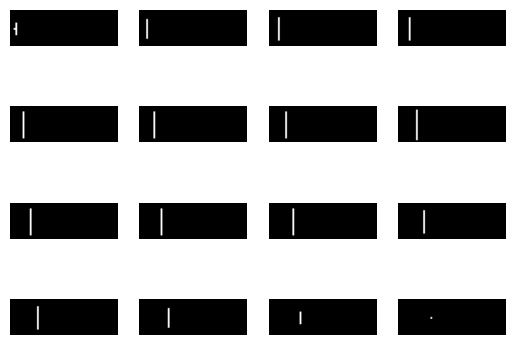

---

## Laboratory (discard this)

In [7]:
n = 800
n_covars = 16
h=20
w=60
circle_radius=8
bz=1.
b2=1.
b3=1.
cv1=0.8
cv2=0.5
sdy=1.
seed=0
outcome_type='continuous'

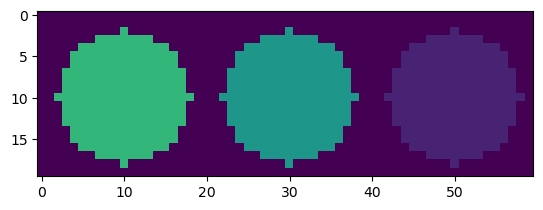

In [19]:
# 1. Covariate Z
Z = torch.rand(n, n_covars)  # uniform(0,1)

# 2. Latent variables
v1_raw = torch.rand(n, 1)
v2_raw = torch.rand(n, 1)
v3 = torch.rand(n, 1) # independent

# Correlate v1 and v2 with a (linear) function of Z.
Zcorr = Z.mean(dim=1, keepdim=True)  # average if multiple covariates
v1 = (1 - cv1) * v1_raw + cv1 * Zcorr
v2 = (1 - cv2) * v2_raw + cv2 * Zcorr

# 3. Build X images.
X = torch.zeros((n, 1, h, w))

centers = [(h//2, w//6), (h//2, w//2), (h//2, 5*w//6)]

def circle_mask(h, w, center, radius):
    Y, Xg = torch.meshgrid(torch.arange(h), torch.arange(w), indexing='ij')
    dist = (Xg - center[1])**2 + (Y - center[0])**2
    return dist <= radius**2

mask1 = circle_mask(h, w, centers[0], circle_radius)
mask2 = circle_mask(h, w, centers[1], circle_radius)
mask3 = circle_mask(h, w, centers[2], circle_radius)

for i in range(n):
    X[i, 0][mask1] = v1[i]
    X[i, 0][mask2] = v2[i]
    X[i, 0][mask3] = v3[i]

plt.imshow(X[0,:].squeeze(), vmin=0, vmax=1)

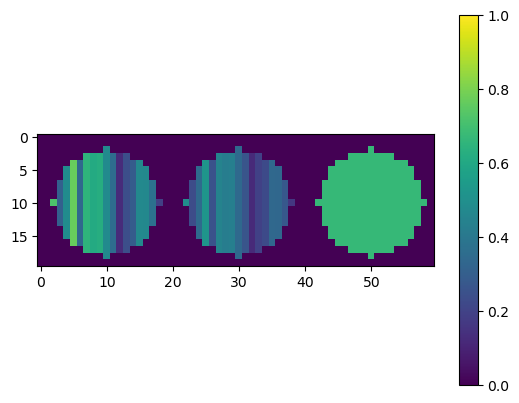

In [ ]:
# 1. Covariate Z
Z = torch.rand(n, n_covars)  # uniform(0,1)

# 2. Latent variables
v1_raw = torch.rand(n, 1)
v2_raw = torch.rand(n, 1)
v3 = torch.rand(n, 1)  # independent


# ---------- helper: split a mask into vertical strips ----------
def split_mask_into_vertical_strips(mask, n_strips):
    """
    Split a boolean mask into n_strips vertical strips.
    Returns a list of boolean masks.
    """
    ys, xs = mask.nonzero(as_tuple=True)
    x_min, x_max = xs.min(), xs.max() + 1
    width = x_max - x_min

    base = width // n_strips
    remainder = width % n_strips

    strips = []
    start = x_min
    for j in range(n_strips):
        wj = base + (1 if j < remainder else 0)
        end = start + wj

        strip = torch.zeros_like(mask)
        strip[ys, xs] = (xs >= start) & (xs < end)
        strips.append(strip)

        start = end

    return strips


# 3. Build X images.
X = torch.zeros((n, 1, h, w))

centers = [(h // 2, w // 6), (h // 2, w // 2), (h // 2, 5 * w // 6)]

def circle_mask(h, w, center, radius):
    Y, Xg = torch.meshgrid(
        torch.arange(h), torch.arange(w), indexing='ij'
    )
    dist = (Xg - center[1])**2 + (Y - center[0])**2
    return dist <= radius**2


mask1 = circle_mask(h, w, centers[0], circle_radius)
mask2 = circle_mask(h, w, centers[1], circle_radius)
mask3 = circle_mask(h, w, centers[2], circle_radius)

# Split confounded circles into strips
mask1_strips = split_mask_into_vertical_strips(mask1, n_covars)
mask2_strips = split_mask_into_vertical_strips(mask2, n_covars)

# Fill images
for i in range(n):

    # v1 circle (confounded, split by Z)
    for j, strip in enumerate(mask1_strips):
        v1_ij = (1 - cv1) * v1_raw[i] + cv1 * Z[i, j]
        X[i, 0][strip] = v1_ij

    # v2 circle (confounded, split by Z)
    for j, strip in enumerate(mask2_strips):
        v2_ij = (1 - cv2) * v2_raw[i] + cv2 * Z[i, j]
        X[i, 0][strip] = v2_ij

    # v3 circle (unconfounded)
    X[i, 0][mask3] = v3[i]


# Visualization
plt.imshow(X[0, 0], vmin=0, vmax=1)
plt.colorbar()


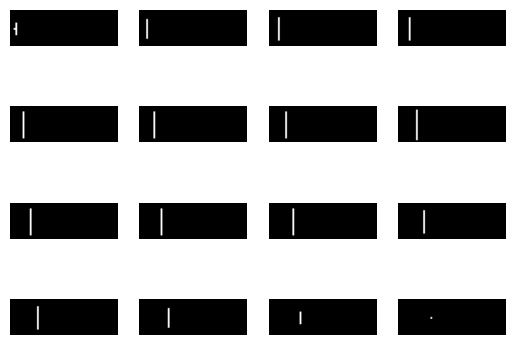

In [44]:
from experiments.simulation_images.dataset import circle_mask, split_mask_into_vertical_strips

import matplotlib.pyplot as plt

img = [] # some array of images
frames = [] # for storing the generated images


h, w = 20, 60
centers = [(h // 2, w // 6), (h // 2, w // 2), (h // 2, 5 * w // 6)]

circle_mask(h, w, centers[0], 8)

ms = split_mask_into_vertical_strips(circle_mask(h, w, centers[0], 8), n_strips=16)

fig = plt.figure()
for i, m in enumerate(ms):
    plt.subplot(4, 4, i + 1)
    plt.imshow(m, cmap='gray')
    plt.axis('off')
plt.show()


In [9]:
# Manual testing.

# Data for training.
# Simulate data.
X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=400, seed=1)
N = X.shape[0]
# Create training and validation.
train_data = CovarDataset(X[:N // 2], Z[:N // 2], y[:N // 2])
val_data = CovarDataset(X[N // 2:], Z[N // 2:], y[N // 2:])
# Create dataloaders.
train_loader = DataLoader(train_data, batch_size= N // 30, shuffle=True)
val_loader = DataLoader(val_data, batch_size= N // 30, shuffle=False)

# Load base model.
model = BaseNetwork(backbone=experiments.traffic_light.backbone.TrafficBackbone, backbone_params={"out_features": 32})
model.load_state_dict(torch.load(
    f"../../outputs/traffic_light/consistency_bz=1.0_corrv1=0.8/traffic_light_nobs=400_nruns=100_20251001-174205/base_1.pth"))
model.eval()

# Load posthoc model.
posthoc_model = PostHocCovarNetwork(model, num_covariates=Z.shape[1])
posthoc_model.load_state_dict(torch.load(
    f"../../outputs/traffic_light/consistency_bz=1.0_corrv1=0.8/traffic_light_nobs=400_nruns=100_20251001-174205/posthoc_1.pth"))
posthoc_model.eval()

PostHocLinearCovarNetwork(
  (backbone): TrafficBackbone(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pool): AdaptiveAvgPool2d(output_size=(4, 4))
    (fc): Linear(in_features=512, out_features=32, bias=True)
  )
  (center_x): Center()
  (fx): Linear(in_features=32, out_features=1, bias=False)
  (fz): Linear(in_features=1, out_features=1, bias=False)
  (center_z): Center()
)

In [59]:
device = 'cpu'
features = []
covariates = []
targets = []

# Data for training.
# Simulate data.
X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=400, seed=1)
N = X.shape[0]
# Create training and validation.
train_data = CovarDataset(X[:N // 2], Z[:N // 2], y[:N // 2])
val_data = CovarDataset(X[N // 2:], Z[N // 2:], y[N // 2:])
# Create dataloaders.
train_loader = DataLoader(train_data, batch_size= N // 30, shuffle=True)
val_loader = DataLoader(val_data, batch_size= N // 30, shuffle=False)

with torch.no_grad():
    for batch in train_loader:
        x = batch["X"].to(device)
        z = batch["Z"].to(device)
        y = batch["y"].to(device)

        x_feat = posthoc_model.backbone(x)
        x_feat = posthoc_model.center_x(x_feat)
        z = posthoc_model.center_z(z)

        features.append(x_feat)
        covariates.append(z)
        targets.append(y)

    for batch in val_loader:
        x = batch["X"].to(device)
        z = batch["Z"].to(device)
        y = batch["y"].to(device)

        x_feat = posthoc_model.backbone(x)
        x_feat = posthoc_model.center_x(x_feat)
        z = posthoc_model.center_z(z)

        features.append(x_feat)
        covariates.append(z)
        targets.append(y)

F = torch.cat(features, dim=0)
P = torch.cat(covariates, dim=0)
o = torch.cat(targets, dim=0)
D = torch.cat([F, P], dim=1)

In [13]:
print("Base model")
print(model.fx.weight)
print("Posthoc model")
posthoc_model.fit(dataloader=train_loader, lam=torch.tensor([0.0, 0.0]))
print(posthoc_model.fx.weight)
print(posthoc_model.fz.weight)
print(posthoc_model.lam)

Base model
Parameter containing:
tensor([[-0.1714,  0.0421, -0.0815, -0.0196, -0.0262,  0.1470,  0.0638,  0.0539,
         -0.1193,  0.1040,  0.1163, -0.1105,  0.1710,  0.1524, -0.0098, -0.0549,
          0.1367, -0.0400, -0.1745,  0.0466,  0.1081, -0.0906, -0.0995, -0.1661,
         -0.0448, -0.0850, -0.0170, -0.0604,  0.0092, -0.0153,  0.1575, -0.0570]],
       requires_grad=True)
Posthoc model
Parameter containing:
tensor([[-1574.6550, -3588.9331,  3670.4180,  1995.0983,   902.8788,   227.7190,
           512.1968,  1848.5096,  2983.9304,  -536.3298,  2989.4600,  1296.9722,
         -1417.5938,    20.9642,  1265.6932,  -414.1363,  2705.7524,  1493.4407,
          1142.1144,  1065.2223,  1325.9673, -2346.3772,   836.2802,  -900.4593,
         -2364.7515, -1590.6740,   -64.7643,  -508.3147,   260.8336, -2721.4893,
            55.2633,  3234.8372]], requires_grad=True)
Parameter containing:
tensor([[-0.5546]], requires_grad=True)
Parameter containing:
tensor(0.)


In [60]:
F_R = pd.DataFrame(F.numpy())
F_R.columns = [f"X{i+1}" for i in range(F.shape[1])]
P_R = pd.DataFrame(P.numpy())
P_R.columns = [f"Z{i+1}" for i in range(P.shape[1])]
o_R = pd.DataFrame(o.numpy())
o_R.columns = ["y"]
data = pd.concat([F_R, P_R, o_R], axis=1)
# save to csv for R


In [15]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


[1] 1.868866
34 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept)  1.44859703
X1          -0.06447076
X2           0.11834204
X3          -0.08911514
X4          -0.07719979
X5          -0.09133914
X6           0.09734818
X7           0.11161640
X8           0.08784211
X9          -0.10207391
X10          0.10721508
X11          0.09732512
X12         -0.11680527
X13          0.09477647
X14          0.09495148
X15         -0.14426493
X16         -0.09130413
X17          0.09889704
X18         -0.09341060
X19         -0.08602277
X20          0.11182993
X21          0.09666920
X22         -0.09625270
X23         -0.09656253
X24         -0.08639193
X25         -0.07627963
X26         -0.07700369
X27         -0.07151538
X28         -0.14616520
X29          0.09172173
X30         -0.10359266
X31          0.10426335
X32         -0.07025619
Z1           0.02715896


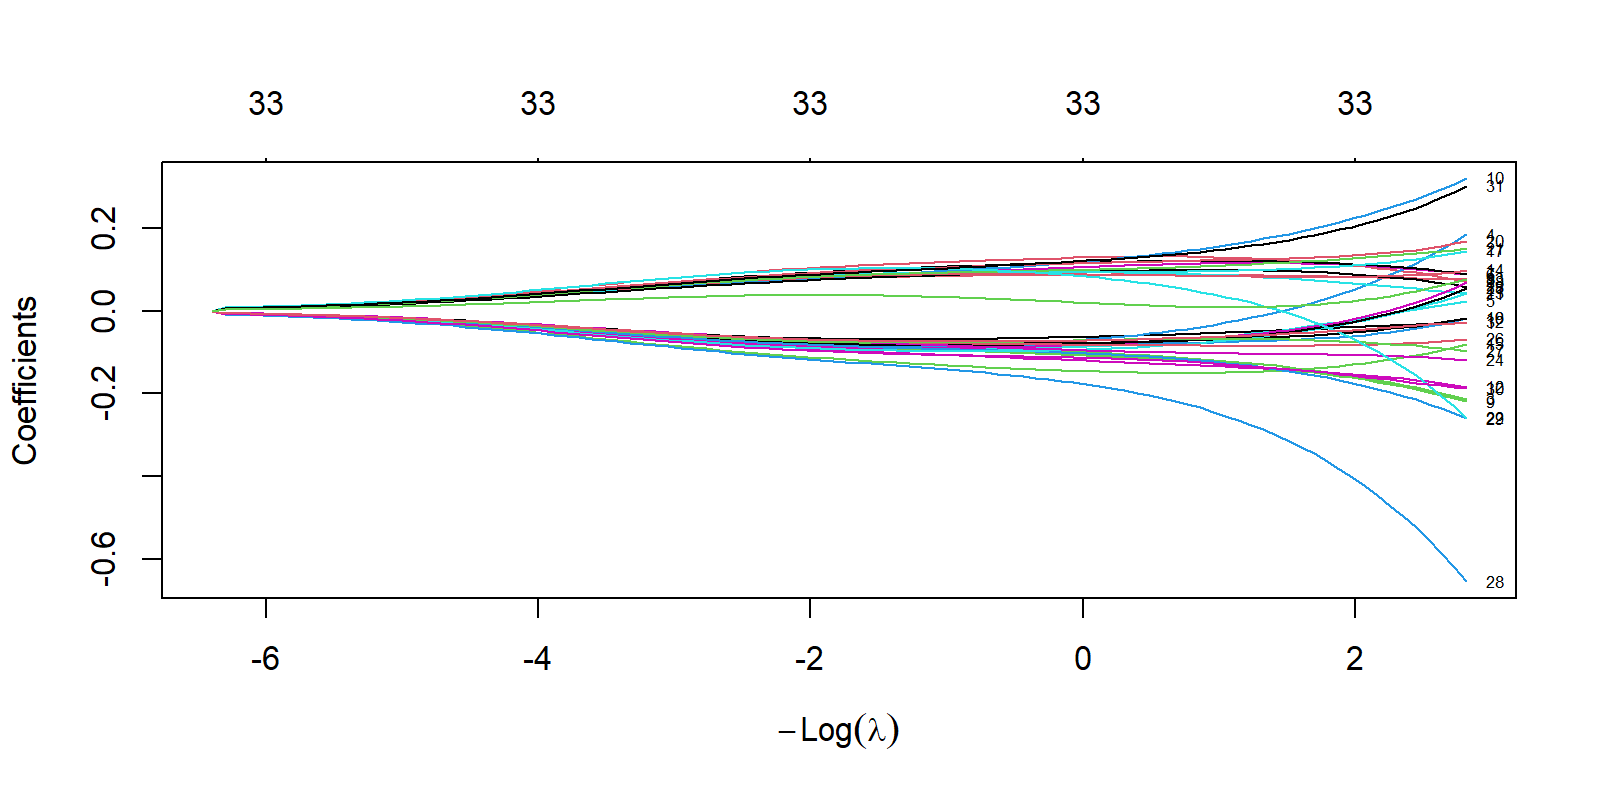

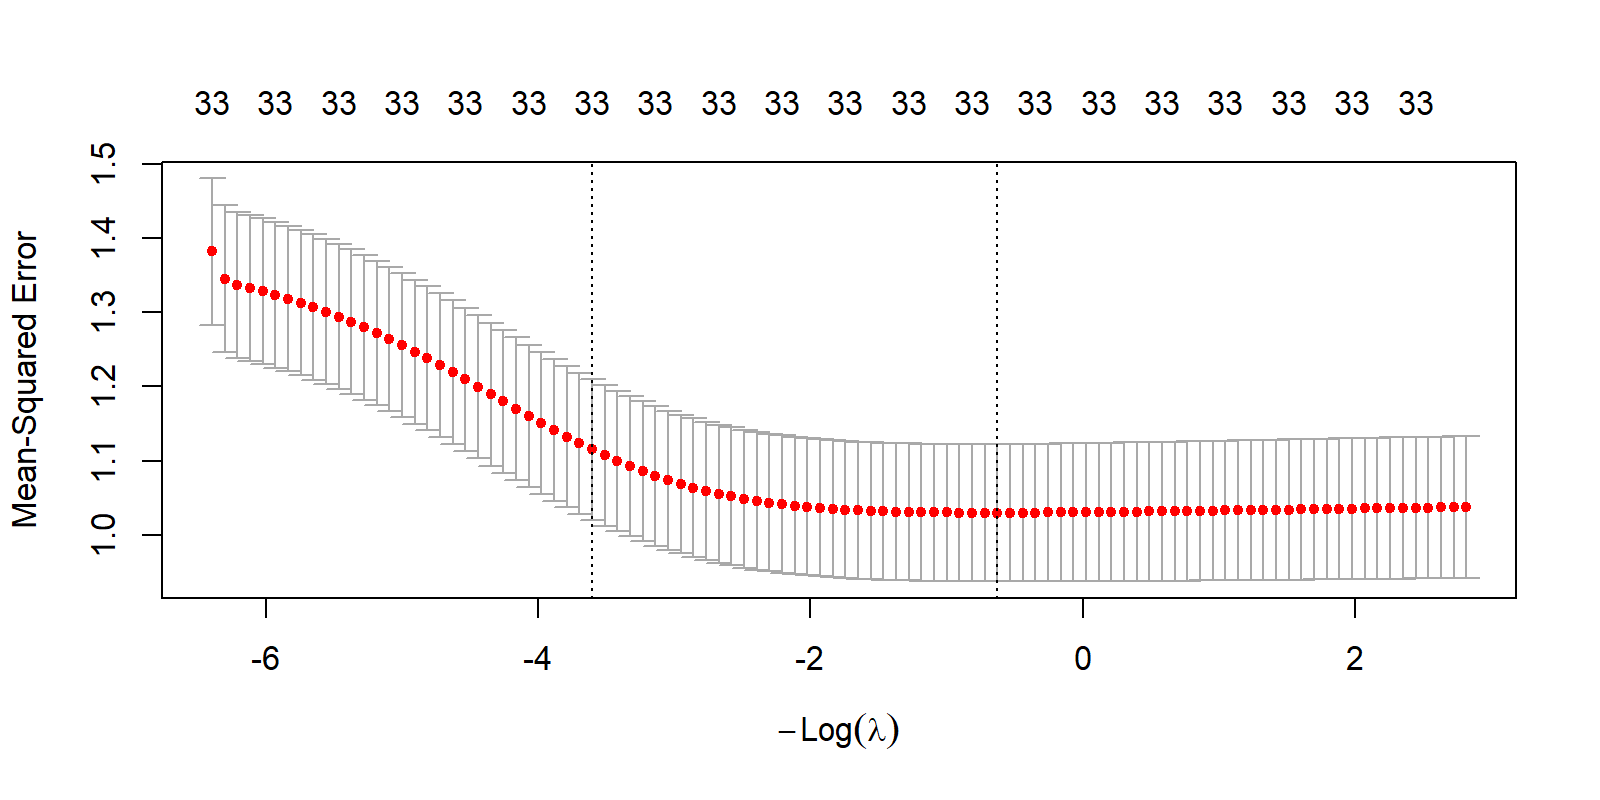

In [61]:
%%R -i data -w 8 -h 4 --units in -r 200

library(glmnet)
X = as.matrix(data[,1:33])
y = as.matrix(data[,34])
p.fac = rep(1,34)
p.fac[34] = 0  # No penalty on covariate.

fit <- glmnet(X, y, alpha=0, penalty_factor = p.fac)
plot(fit, label=TRUE)

# Using glmnet function to build the ridge regression in r
ridge_cv <- cv.glmnet(X, y, alpha=0, penalty_factor = p.fac)
plot(ridge_cv)

best_lambda <- ridge_cv$lambda.min
print(best_lambda)

# Fit using best lambda.
m <- glmnet(X, y, alpha=0, penalty_factor = p.fac, lambda  = best_lambda)
coef(m)

[1] 3.162278
34 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept)  1.45207678
X1          -0.08401881
X2           0.12061197
X3          -0.08576181
X4          -0.10157741
X5          -0.11655860
X6           0.08617245
X7           0.10530225
X8           0.09002295
X9          -0.09379977
X10          0.08254998
X11          0.09746615
X12         -0.10300468
X13          0.07872277
X14          0.10017503
X15         -0.12374969
X16         -0.08891220
X17          0.09784530
X18         -0.09277129
X19         -0.08614463
X20          0.10120333
X21          0.08691490
X22         -0.08839693
X23         -0.10608365
X24         -0.07706328
X25         -0.07408385
X26         -0.07317587
X27         -0.08418012
X28         -0.11893888
X29          0.11108437
X30         -0.10249594
X31          0.09712172
X32         -0.08281138
Z1           0.03575306


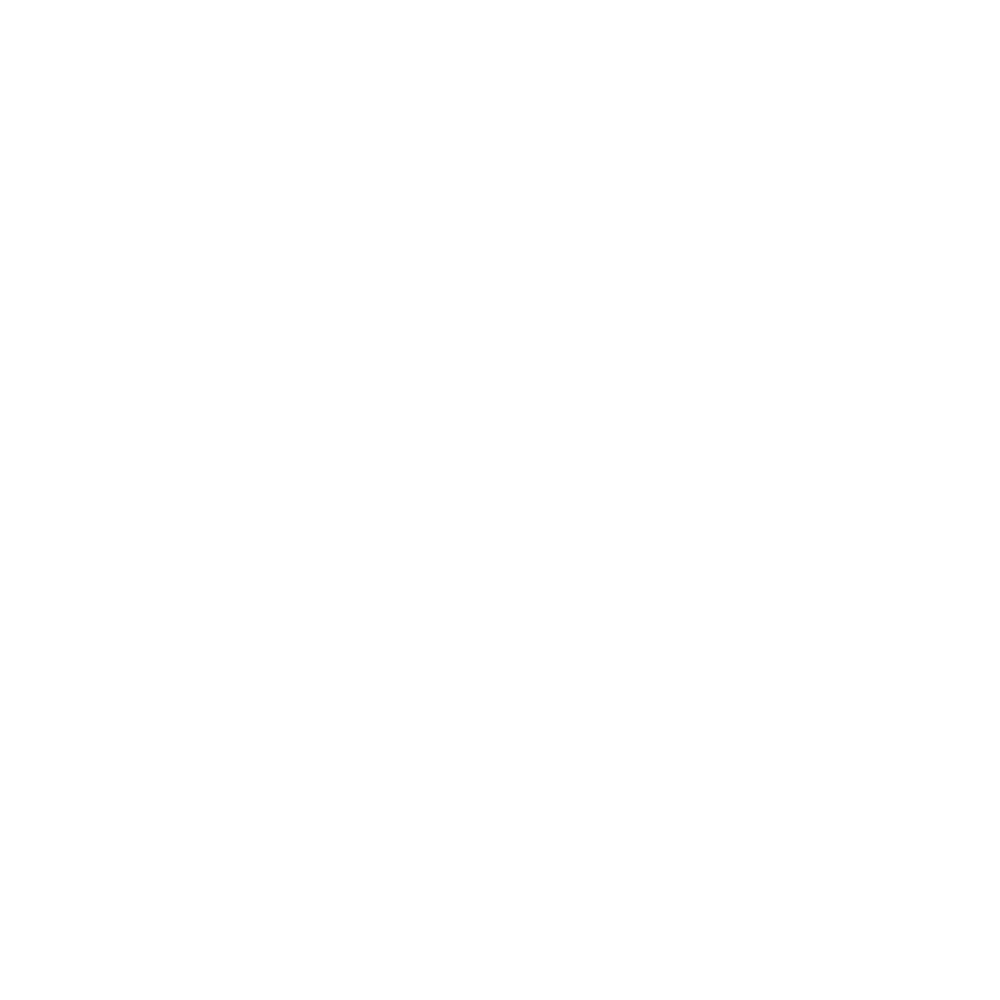

In [54]:
# Compute predictions on validation set
device = 'cpu'

X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=800, seed=1234)
N = X.shape[0]
test_data = CovarDataset(X, Z, y)
test_loader = DataLoader(test_data, batch_size= N // 30, shuffle=False)

val_losses = []

for batch in test_loader:
    X_val, Z_val, y_val = batch["X"].to(device), batch["Z"].to(device), batch["y"].to(device)
    # Forward pass (linear model: yhat = fx*X + fz*Z + intercept)
    yhat = model(X_val).squeeze().detach().cpu()
    loss = ((y_val - yhat)**2).mean()
    val_losses.append(loss.item())

mean_val_loss = sum(val_losses) / len(val_losses)
print(mean_val_loss)

1.5259086393540906


In [66]:
print(mean_val_loss)  # 1.57676213234663 (lam = 1)

1.578254222869873


In [54]:
# Suppose val_loader yields batches: (X_val, Z_val, y_val)
# Candidate lambda values
lambda_grid = torch.logspace(-5, 5, 20)  # 20 values from 1e-5 to 1e2

best_lam = None
best_loss = float('inf')

for lam in lambda_grid:
    # Fit ridge on training data (replace X_train, Z_train, y_train with your tensors)
    posthoc_model._linear_fit_from_loader(train_loader, lam=lam.item())

    # Compute predictions on validation set
    val_losses = []
    for batch in val_loader:
        X_val, Z_val, y_val = batch["X"].to(device), batch["Z"].to(device), batch["y"].to(device)
        # Forward pass (linear model: yhat = fx*X + fz*Z + intercept)
        yhat = posthoc_model(X, Z).squeeze().detach().cpu()
        loss = ((y_val - yhat)**2).mean()
        val_losses.append(loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)

    print(f"Lambda: {lam.item():.5f}, validation MSE: {mean_val_loss:.5f}")

    if mean_val_loss < best_loss:
        best_loss = mean_val_loss
        best_lam = lam.item()

print(f"Optimal lambda: {best_lam:.5f}, validation MSE: {best_loss:.5f}")

Lambda: 0.00001, validation MSE: 1.66398
Lambda: 0.00003, validation MSE: 1.66095
Lambda: 0.00011, validation MSE: 1.65761
Lambda: 0.00038, validation MSE: 1.65459
Lambda: 0.00127, validation MSE: 1.65248
Lambda: 0.00428, validation MSE: 1.65123
Lambda: 0.01438, validation MSE: 1.65033
Lambda: 0.04833, validation MSE: 1.64893
Lambda: 0.16238, validation MSE: 1.64599
Lambda: 0.54556, validation MSE: 1.64122
Lambda: 1.83298, validation MSE: 1.63674
Lambda: 6.15848, validation MSE: 1.63257
Lambda: 20.69138, validation MSE: 1.62416
Lambda: 69.51928, validation MSE: 1.60285
Lambda: 233.57214, validation MSE: 1.56462
Lambda: 784.75995, validation MSE: 1.53248
Lambda: 2636.65088, validation MSE: 1.52221
Lambda: 8858.66797, validation MSE: 1.52080
Lambda: 29763.51367, validation MSE: 1.52072
Lambda: 100000.00000, validation MSE: 1.52074
Optimal lambda: 29763.51367, validation MSE: 1.52072
